# EDA – eBay Tech Deals
**COSC 482 – Data Science and Web Scraping | Spring 2026**

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
df = pd.read_csv('cleaned_ebay_deals.csv')
df.head()

,timestamp,title,price,original_price,shipping,item_url,discount_percentage
0,2026-03-17 17:32:51,Samsung Galaxy Z TriFold 1TB 16GB Crafted Blac...,4599.00,4599.00,Shipping info unavailable,NaN,0.0
1,2026-03-17 17:32:51,Apple iPhone 4 4s -8GB 16 GB 32GB 64GB - Black...,35.25,35.25,Shipping info unavailable,NaN,0.0
2,2026-03-17 17:32:51,"Huawei P60 Pro 5G Unlocked 48MP 6.67"" Harmony ...",360.63,360.63,Shipping info unavailable,NaN,0.0
3,2026-03-17 17:32:51,sealed Huawei honor 9 lite 6+128GB Unlocked go...,54.54,54.54,Shipping info unavailable,NaN,0.0
4,2026-03-17 17:32:51,"2020 Apple M1 MacBook Air 13.3"" 8GB/512GB - (S...",399.99,399.99,Shipping info unavailable,NaN,0.0


## 1. Time Series Analysis

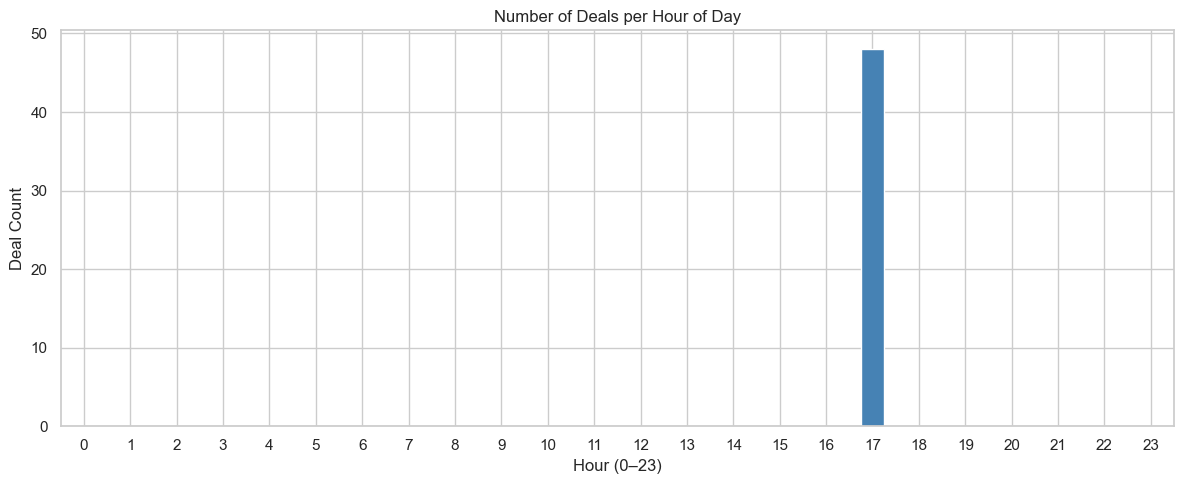

In [11]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
df['hour'] = df['timestamp'].dt.hour

deals_per_hour = df.groupby('hour').size().reindex(range(24), fill_value=0)

plt.figure(figsize=(12, 5))
deals_per_hour.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Deals per Hour of Day')
plt.xlabel('Hour (0–23)')
plt.ylabel('Deal Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_deals_per_hour.png', dpi=150)
plt.show()

## 2. Price and Discount Analysis

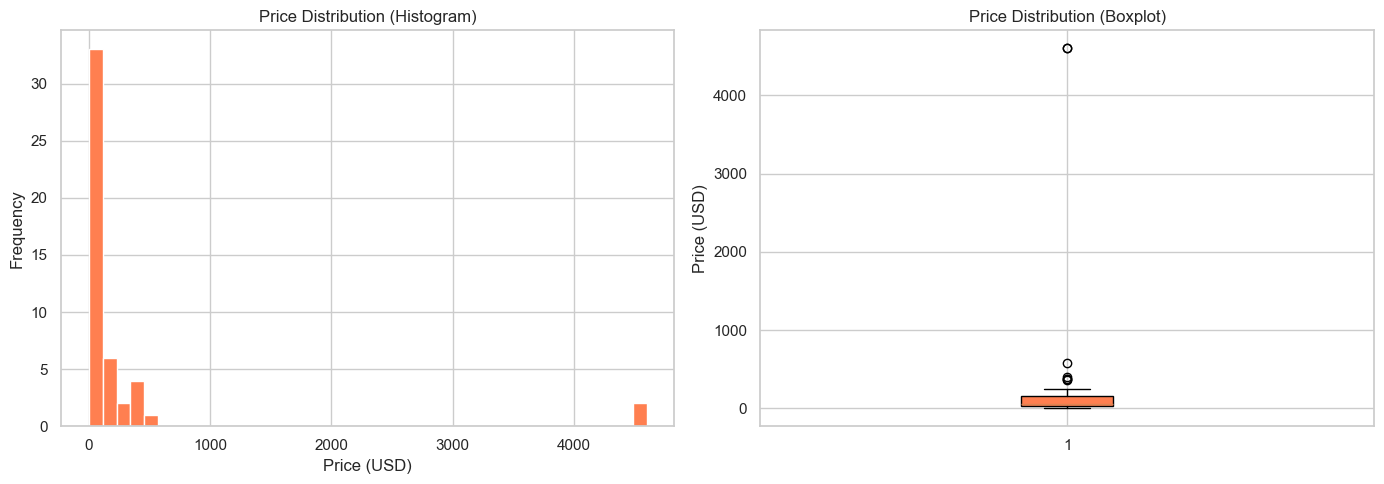

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price'].dropna(), bins=40, color='coral', edgecolor='white')
axes[0].set_title('Price Distribution (Histogram)')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df['price'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', color='black'))
axes[1].set_title('Price Distribution (Boxplot)')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.savefig('plot_price_distribution.png', dpi=150)
plt.show()

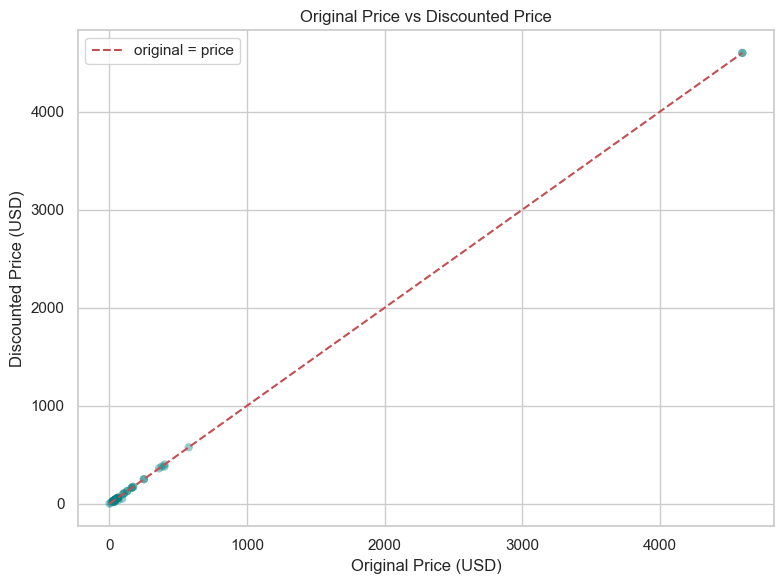

In [13]:
# Scatter: original_price vs price
plt.figure(figsize=(8, 6))
plt.scatter(df['original_price'], df['price'], alpha=0.4, color='teal', edgecolors='none')
max_val = max(df['original_price'].max(), df['price'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='original = price')
plt.title('Original Price vs Discounted Price')
plt.xlabel('Original Price (USD)')
plt.ylabel('Discounted Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('plot_price_scatter.png', dpi=150)
plt.show()

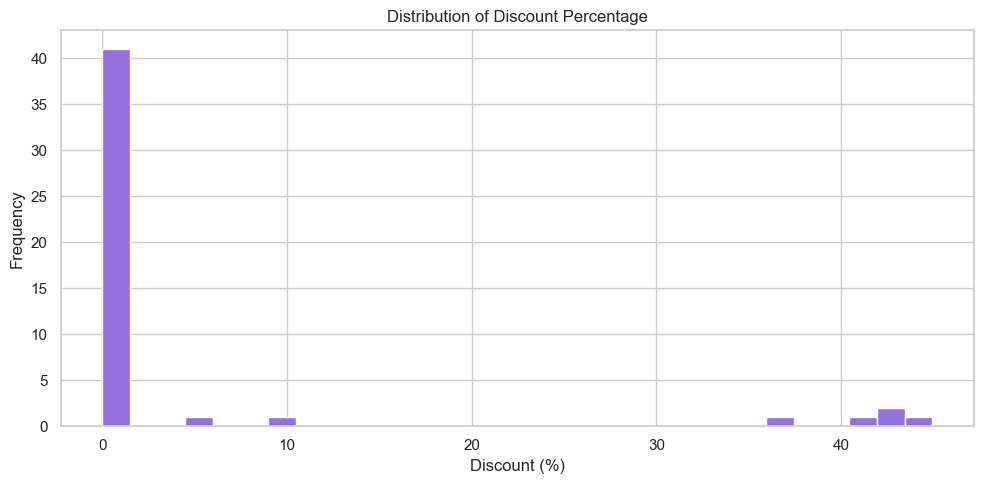

In [14]:
# Discount percentage distribution
plt.figure(figsize=(10, 5))
df['discount_percentage'].dropna().plot(kind='hist', bins=30, color='mediumpurple', edgecolor='white')
plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plot_discount_distribution.png', dpi=150)
plt.show()

## 3. Shipping Information Analysis

shipping
Shipping info unavailable    48
Name: count, dtype: int64


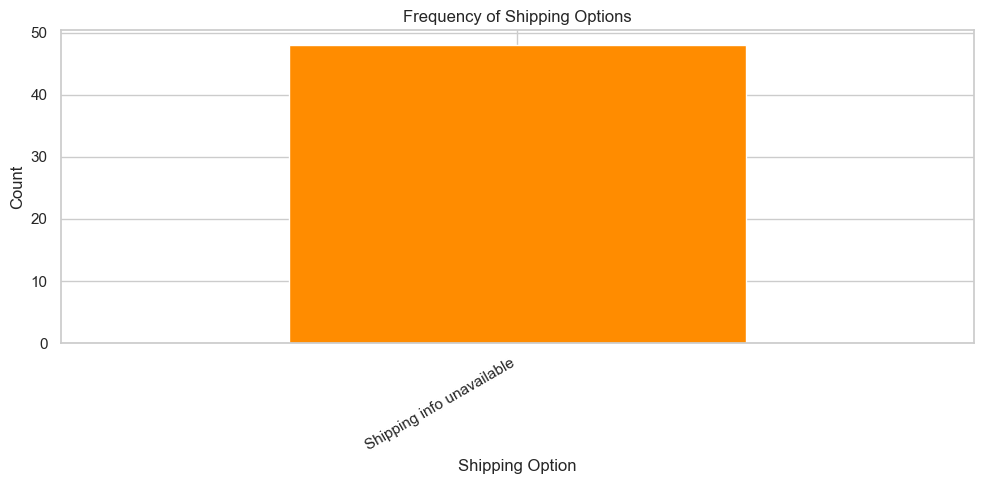

In [15]:
shipping_counts = df['shipping'].value_counts()
print(shipping_counts)

plt.figure(figsize=(10, 5))
shipping_counts.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Frequency of Shipping Options')
plt.xlabel('Shipping Option')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plot_shipping.png', dpi=150)
plt.show()

## 4. Text Analysis on Product Titles

Apple      11
Samsung     4
iPhone      3
Laptop      1
Tablet      0
Gimbal      0
dtype: int64


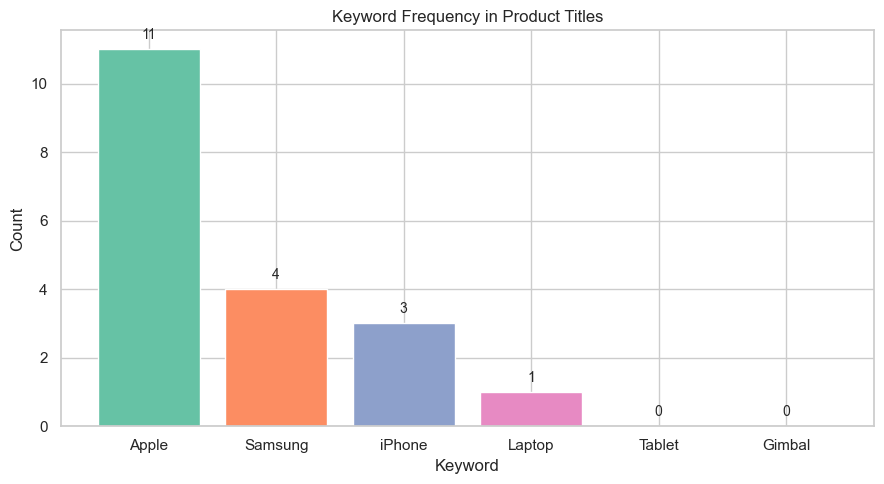

In [16]:
keywords = ['Apple', 'Samsung', 'Laptop', 'iPhone', 'Tablet', 'Gimbal']
titles_lower = df['title'].fillna('').str.lower()
keyword_counts = {kw: titles_lower.str.contains(kw.lower()).sum() for kw in keywords}

kw_series = pd.Series(keyword_counts).sort_values(ascending=False)
print(kw_series)

plt.figure(figsize=(9, 5))
palette = sns.color_palette('Set2', len(kw_series))
bars = plt.bar(kw_series.index, kw_series.values, color=palette, edgecolor='white')
plt.title('Keyword Frequency in Product Titles')
plt.xlabel('Keyword')
plt.ylabel('Count')
for bar, val in zip(bars, kw_series.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_keywords.png', dpi=150)
plt.show()

## 5. Price Difference Analysis

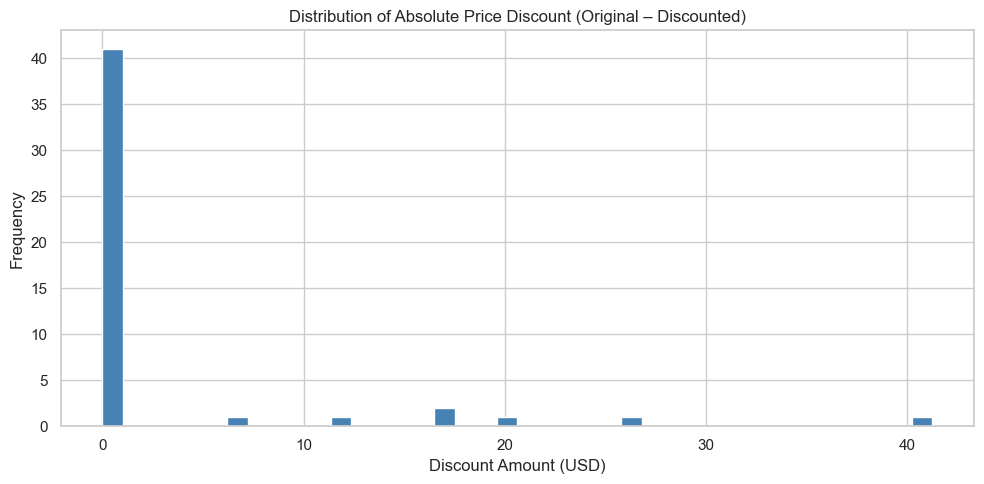

In [17]:
df['absolute_discount'] = df['original_price'] - df['price']

plt.figure(figsize=(10, 5))
df['absolute_discount'].dropna().plot(kind='hist', bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Absolute Price Discount (Original – Discounted)')
plt.xlabel('Discount Amount (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plot_price_diff.png', dpi=150)
plt.show()

## 6. Top 5 Deals by Discount Percentage

In [18]:
top5 = (
    df[['title', 'price', 'original_price', 'discount_percentage', 'item_url']]
    .dropna(subset=['discount_percentage'])
    .sort_values('discount_percentage', ascending=False)
    .head(5)
    .reset_index(drop=True)
)
top5.index += 1
print(top5.to_string())
top5

                                                                           title  price  original_price  discount_percentage  item_url
1        Genuine / Official Samsung Galaxy Watch Ultra Marine Band - Green - New  50.53           91.78                44.94       NaN
2        Genuine / Official Apple USB-C to Lightning Adapter A2868 - White - New  22.07           38.57                42.78       NaN
3        Genuine / Official Apple USB-C to Lightning Adapter A2868 - White - New  22.07           38.57                42.78       NaN
4   Genuine / Official Apple iPhone 13 Pro Clear / Transparent Case with MagSafe  38.56           65.18                40.84       NaN
5  Hard Case for Sony WH-CH720N/WH-XB910N/ULT WEAR/MDR-M1/MDR-MV1/WH-1000XM5 JBL  21.27           33.24                36.01       NaN


,title,price,original_price,discount_percentage,item_url
1,Genuine / Official Samsung Galaxy Watch Ultra ...,50.53,91.78,44.94,NaN
2,Genuine / Official Apple USB-C to Lightning Ad...,22.07,38.57,42.78,NaN
3,Genuine / Official Apple USB-C to Lightning Ad...,22.07,38.57,42.78,NaN
4,Genuine / Official Apple iPhone 13 Pro Clear /...,38.56,65.18,40.84,NaN
5,Hard Case for Sony WH-CH720N/WH-XB910N/ULT WEA...,21.27,33.24,36.01,NaN
